In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [2]:
#TASK 1 Starts

import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head(10)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
df.shape

(1470, 35)

In [4]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#There are no duplicate values in any column.

In [5]:
#Target Column
print(df['Attrition'].unique())

['Yes' 'No']


In [6]:
#Counts Attrition Values
count=df['Attrition'].value_counts()
print(count)

#Rate
(df['Attrition'].value_counts(normalize=True) * 100).round(2)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


,proportion
Attrition,
No,83.88
Yes,16.12


In [7]:
#Numerical columns
numeric_cols= df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}) : {numeric_cols}")
print("\n")

#Categorical columns
categorical_cols= df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns ({len(categorical_cols)}) : {categorical_cols}")

Numeric columns (26) : ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


Categorical columns (9) : ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [ ]:
#The attrition rate is imbalanced because the rate of employees who stayed was 83.88% whereas the rate of employees who left was only 16.12%.

In [8]:
#TASK 2 Starts

print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [ ]:
# There are no null values in any column.

In [9]:
df = df.drop(columns=['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount'])

In [10]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,4,Male,...,3,3,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,3,Female,...,4,1,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,4,Male,...,4,2,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,4,Male,...,4,2,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,3,Male,...,3,2,2,17,3,2,7,7,7,7


In [11]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [12]:
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)
bool_cols = df_encoded.select_dtypes(include='bool').columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded.head(10)

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,0,0,0,0,0,1,0,0,1,1
1,49,0,279,8,1,3,61,2,2,2,...,0,0,0,0,1,0,0,1,0,0
2,37,1,1373,2,2,4,92,2,1,3,...,1,0,0,0,0,0,0,0,1,1
3,33,0,1392,3,4,4,56,3,1,3,...,0,0,0,0,1,0,0,1,0,1
4,27,0,591,2,1,1,40,3,1,2,...,1,0,0,0,0,0,0,1,0,0
5,32,0,1005,2,2,4,79,3,1,4,...,1,0,0,0,0,0,0,0,1,0
6,59,0,1324,3,3,3,81,4,1,1,...,1,0,0,0,0,0,0,1,0,1
7,30,0,1358,24,1,4,67,3,1,3,...,1,0,0,0,0,0,0,0,0,0
8,38,0,216,23,3,4,44,2,3,3,...,0,0,1,0,0,0,0,0,1,0
9,36,0,1299,27,3,3,94,3,2,3,...,0,0,0,0,0,0,0,1,0,0


In [13]:
from sklearn.preprocessing import StandardScaler

#Feature from encoded dataframe
X = df_encoded.drop(columns=['Attrition'])
#Target from encoded dataframe
y = df_encoded['Attrition']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #list
X_scaled = pd.DataFrame(X_scaled, columns=X.columns) #Dataframe

print(X_scaled.head())

        Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0  0.446350   0.742527         -1.010909  -0.891688                -0.660531   
1  1.322365  -1.297775         -0.147150  -1.868426                 0.254625   
2  0.008343   1.414363         -0.887515  -0.891688                 1.169781   
3 -0.429664   1.461466         -0.764121   1.061787                 1.169781   
4 -1.086676  -0.524295         -0.887515  -1.868426                -1.575686   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0    1.383138        0.379672 -0.057788         1.153254      -0.108350  ...   
1   -0.240677       -1.026167 -0.057788        -0.660853      -0.291719  ...   
2    1.284725       -1.026167 -0.961486         0.246200      -0.937654  ...   
3   -0.486709        0.379672 -0.961486         0.246200      -0.763634  ...   
4   -1.274014        0.379672 -0.961486        -0.660853      -0.644858  ...   

   JobRole_Laboratory Technician  JobR

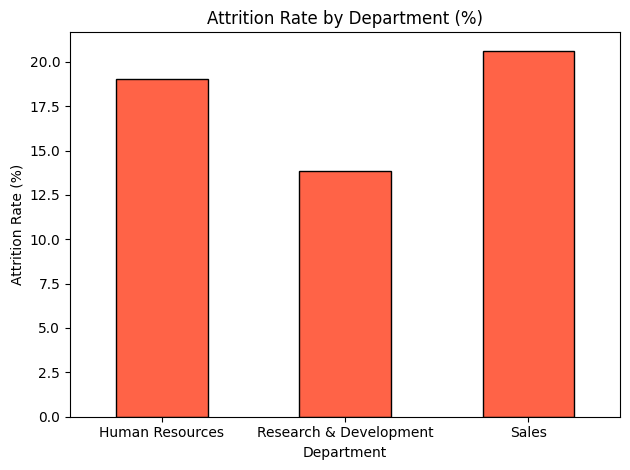

In [14]:
#TASK 3 Starts

#Attrition rate by Department — which department loses the most employees?
import pandas as pd
import matplotlib.pyplot as plt
df_eda = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df_eda['Attrition'] = df_eda['Attrition'].map({'Yes': 1, 'No': 0})

dept_attrition = df_eda.groupby('Department')['Attrition'].mean() * 100
dept_attrition.plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Attrition Rate by Department (%)')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


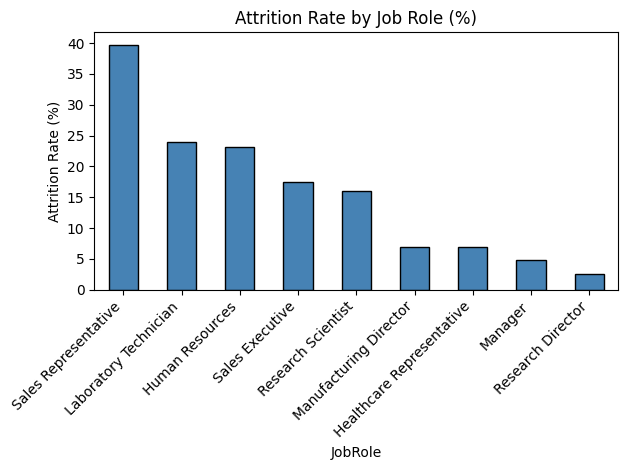

In [ ]:
#Attrition rate by Job Role — which roles have the highest exit rate?
import pandas as pd
import matplotlib.pyplot as plt
df_eda = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df_eda['Attrition'] = df_eda['Attrition'].map({'Yes': 1, 'No': 0})

role_attrition = df_eda.groupby('JobRole')['Attrition'].mean() * 100
role_attrition.sort_values(ascending=False).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Attrition Rate by Job Role (%)')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#Attrition vs Monthly Income — do lower paid employees leave more?
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df_eda = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df_eda['Attrition'] = df_eda['Attrition'].map({'Yes': 1, 'No': 0})

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income vs Attrition')
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.tight_layout()
plt.show()

In [ ]:
#Attrition vs Work-Life Balance rating — is there a visible pattern?
import pandas as pd
import matplotlib.pyplot as plt
df_eda = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df_eda['Attrition'] = df_eda['Attrition'].map({'Yes': 1, 'No': 0})

wlb_attrition = df_eda.groupby('WorkLifeBalance')['Attrition'].mean() * 100
wlb_attrition.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Attrition Rate by Work-Life Balance Rating (%)')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Work-Life Balance (1=Bad, 4=Best)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

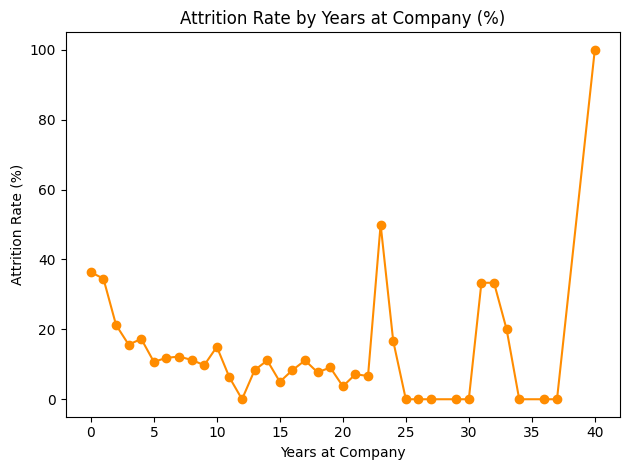

In [ ]:
#Attrition vs Years at Company — at what point in tenure do employees leave most?
import pandas as pd
import matplotlib.pyplot as plt
df_eda = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df_eda['Attrition'] = df_eda['Attrition'].map({'Yes': 1, 'No': 0})

years_attrition = df_eda.groupby('YearsAtCompany')['Attrition'].mean() * 100
years_attrition.plot(kind='line', marker='o', color='darkorange')
plt.title('Attrition Rate by Years at Company (%)')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Years at Company')
plt.tight_layout()
plt.show()

In [15]:
print("Attrition by Department:\n", df_eda.groupby('Department')['Attrition'].mean().round(3) * 100)

print("\nAttrition by JobRole:\n", df_eda.groupby('JobRole')['Attrition'].mean().round(3) * 100)

print("\nAvg Income - Left:", df_eda[df_eda['Attrition']==1]['MonthlyIncome'].mean().round(0))

print("Avg Income - Stayed:", df_eda[df_eda['Attrition']==0]['MonthlyIncome'].mean().round(0))

print("\nAttrition by WorkLifeBalance:\n", df_eda.groupby('WorkLifeBalance')['Attrition'].mean().round(3) * 100)

Attrition by Department:
 Department
Human Resources           19.0
Research & Development    13.8
Sales                     20.6
Name: Attrition, dtype: float64

Attrition by JobRole:
 JobRole
Healthcare Representative     6.9
Human Resources              23.1
Laboratory Technician        23.9
Manager                       4.9
Manufacturing Director        6.9
Research Director             2.5
Research Scientist           16.1
Sales Executive              17.5
Sales Representative         39.8
Name: Attrition, dtype: float64

Avg Income - Left: 4787.0
Avg Income - Stayed: 6833.0

Attrition by WorkLifeBalance:
 WorkLifeBalance
1    31.2
2    16.9
3    14.2
4    17.6
Name: Attrition, dtype: float64


In [ ]:
#Business Insights from EDA

#1. The Sales department has the highest attrition rate at 20.6%, followed by Human Resources at 19% — both significantly higher than R&D at 13.8%.
#2. The Sales Representatives have an alarming attrition rate of 39.8% — nearly 1 in 2 employees leave. Laboratory Technicians (23.9%) and Human Resources roles (23.1%) also show high exit rates.
#3. The Employees who left earned an average of ₹4,787/month compared to ₹6,833 for those who stayed — a difference of ₹2,046/month, suggesting low compensation is a strong driver of attrition.
#4. The Employees with a Work-Life Balance rating of 1 (Bad) have the highest attrition at 31.2% — more than double the rate of those with rating 3 (Good) at 14.2%.
#5. The Managers and the Research Directors have the lowest attrition rates at 4.9% and 2.5% respectively, indicating senior/leadership roles are far more stable than frontline roles.

In [16]:
#TASK 4 Starts

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (1176, 44)
Test size: (294, 44)


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

#compares prediction Vs actual answers through a report:
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print("AUC-ROC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]).round(3))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.92      0.74      0.82       255
           1       0.26      0.59      0.36        39

    accuracy                           0.72       294
   macro avg       0.59      0.66      0.59       294
weighted avg       0.83      0.72      0.76       294

AUC-ROC: 0.766


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

#compares prediction Vs actual answers through a report:
print("Random Forest:")
print(classification_report(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]).round(3))

Random Forest:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.75      0.08      0.14        39

    accuracy                           0.87       294
   macro avg       0.81      0.54      0.54       294
weighted avg       0.86      0.87      0.83       294

AUC-ROC: 0.734


In [19]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

#compares prediction Vs actual answers through a report:
print("Gradient Boosting:")
print(classification_report(y_test, y_pred_gb))
print("AUC-ROC:", roc_auc_score(y_test, gb.predict_proba(X_test)[:,1]).round(3))

Gradient Boosting:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       255
           1       0.54      0.18      0.27        39

    accuracy                           0.87       294
   macro avg       0.71      0.58      0.60       294
weighted avg       0.84      0.87      0.84       294

AUC-ROC: 0.779


In [20]:
# COMPARISON TABLE Of ALL THE RESULTS
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr), 3),
        round(accuracy_score(y_test, y_pred_rf), 3),
        round(accuracy_score(y_test, y_pred_gb), 3)
    ],
    'Precision': [
        round(precision_score(y_test, y_pred_lr), 3),
        round(precision_score(y_test, y_pred_rf), 3),
        round(precision_score(y_test, y_pred_gb), 3)
    ],
    'Recall': [
        round(recall_score(y_test, y_pred_lr), 3),
        round(recall_score(y_test, y_pred_rf), 3),
        round(recall_score(y_test, y_pred_gb), 3)
    ],
    'F1 Score': [
        round(f1_score(y_test, y_pred_lr), 3),
        round(f1_score(y_test, y_pred_rf), 3),
        round(f1_score(y_test, y_pred_gb), 3)
    ],
    'AUC-ROC': [
        round(roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]), 3),
        round(roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]), 3),
        round(roc_auc_score(y_test, gb.predict_proba(X_test)[:,1]), 3)
    ]
})

print(results)

                 Model  Accuracy  Precision  Recall  F1 Score  AUC-ROC
0  Logistic Regression     0.718      0.256   0.590     0.357    0.766
1        Random Forest     0.874      0.750   0.077     0.140    0.734
2    Gradient Boosting     0.871      0.538   0.179     0.269    0.779


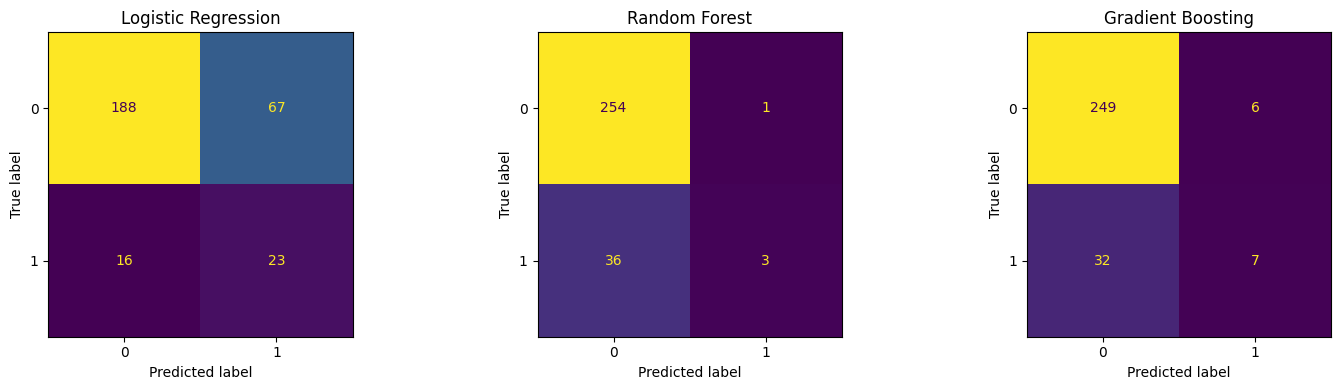

In [21]:
#TASK 5 Starts

#Confusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [('Logistic Regression', y_pred_lr),
          ('Random Forest', y_pred_rf),
          ('Gradient Boosting', y_pred_gb)]

for ax, (name, y_pred) in zip(axes, models):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [ ]:
# BEST MODEL: Logistic Regression

# Reason:
# - Highest Recall for class 1 (leavers) at 0.59 meaning it catches the most at-risk employees
# - In an HR context, missing an employee who is about to leave (false negative) is more costly than a false alarm (false positive)
# - The AUC-ROC of 0.766 is competitive with Gradient Boosting (0.779)
# - It is the most explainable model, HR teams can understand which factors drive the prediction

# Random Forest and Gradient Boosting had higher accuracy (0.87) but only caught 8% and 18% of actual leavers, making them unreliable for this use case.

In [22]:
import pandas as pd
import numpy as np

#get coefficients from logistic regression
feature_importance = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': np.abs(lr.coef_[0])
})

In [27]:
#Top 10 most important features driving employee exit are:
top10 = feature_importance.sort_values('Importance', ascending=False).head(10)
print(top10)

                             Feature  Importance
19                    YearsAtCompany    0.972607
43                      OverTime_Yes    0.925505
34     JobRole_Laboratory Technician    0.903361
42              MaritalStatus_Single    0.775750
20                YearsInCurrentRole    0.724167
23  BusinessTravel_Travel_Frequently    0.710158
26                  Department_Sales    0.621011
40      JobRole_Sales Representative    0.611916
22              YearsWithCurrManager    0.560362
33           JobRole_Human Resources    0.540362


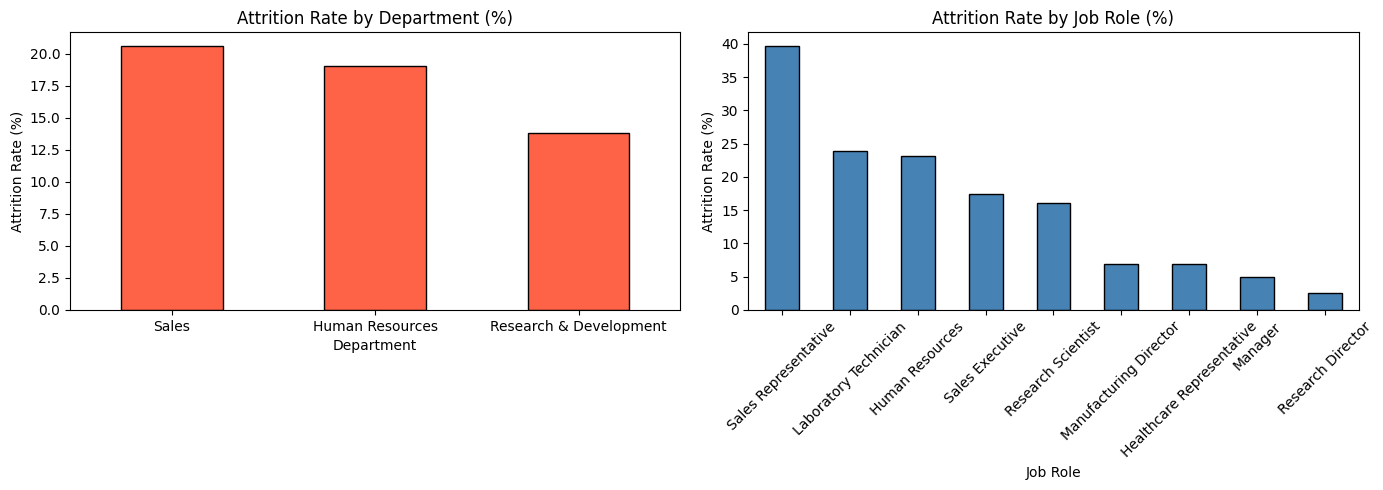

In [31]:
#TASK 6 Starts

#Chart 1: Bar chart showing attrition rate by Department and Job Role
import os
os.makedirs('charts', exist_ok=True)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
# Department
dept_attrition = df.groupby('Department')['Attrition'].mean() * 100
dept_attrition.sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='tomato', edgecolor='black'
)
axes[0].set_title('Attrition Rate by Department (%)')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_xlabel('Department')
axes[0].tick_params(axis='x', rotation=0)

# Job Role
role_attrition = df.groupby('JobRole')['Attrition'].mean() * 100
role_attrition.sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black'
)
axes[1].set_title('Attrition Rate by Job Role (%)')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_xlabel('Job Role')
axes[1].tick_params(axis='x', rotation=45)

plt.savefig('charts/chart1_attrition_by_dept_role.png', dpi=150)
plt.tight_layout()
plt.show()

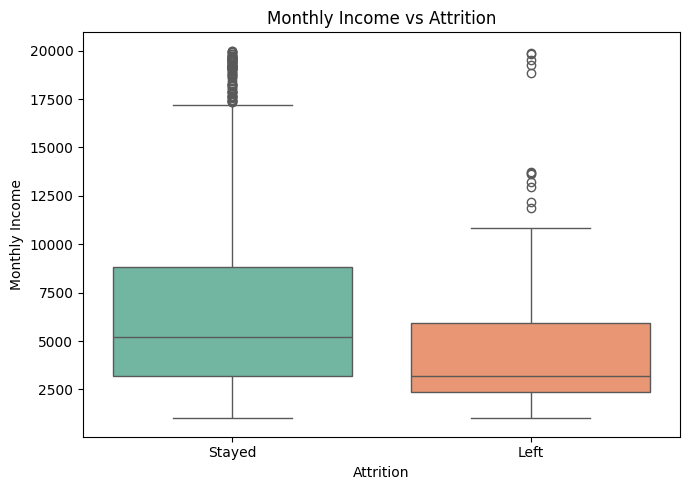

In [32]:
#Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
import os
os.makedirs('charts', exist_ok=True)
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, hue='Attrition', palette='Set2', legend=False)
plt.title('Monthly Income vs Attrition')
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.savefig('charts/chart2_income_vs_attrition.png', dpi=150)
plt.show()

<Figure size 600x500 with 0 Axes>

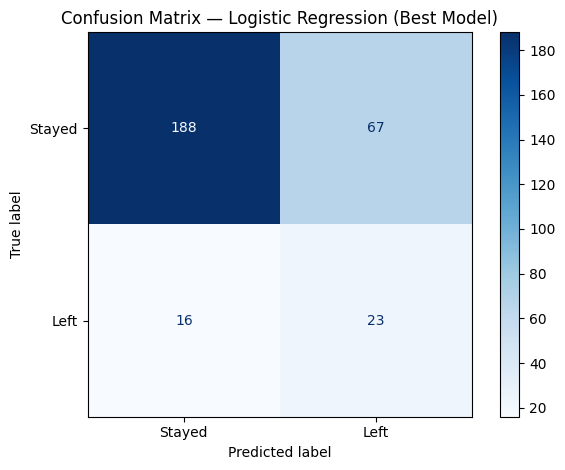

In [33]:
#Chart 3: Confusion Matrix heatmap for your best model
import os
os.makedirs('charts', exist_ok=True)
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Stayed', 'Left'],
    cmap='Blues'
)
plt.title('Confusion Matrix — Logistic Regression (Best Model)')
plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', dpi=150)
plt.show()

<Figure size 800x600 with 0 Axes>

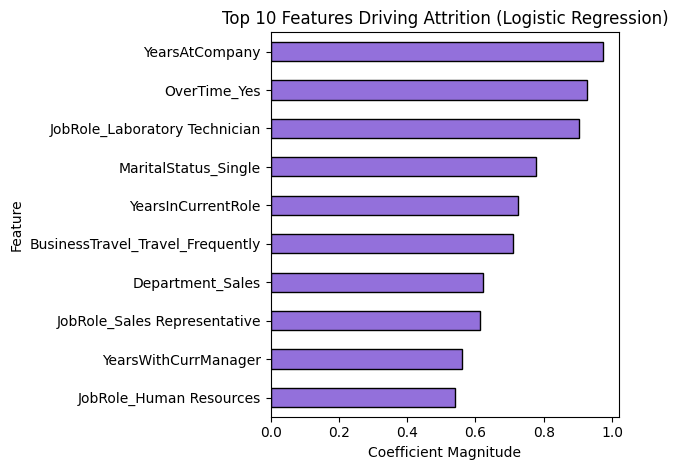

In [34]:
#Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model
import os
os.makedirs('charts', exist_ok=True)
import numpy as np

feature_importance = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': np.abs(lr.coef_[0])
})
top10 = feature_importance.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8, 6))
top10.sort_values('Importance').plot(
    kind='barh', x='Feature', y='Importance',
    color='mediumpurple', edgecolor='black', legend=False
)
plt.title('Top 10 Features Driving Attrition (Logistic Regression)')
plt.xlabel('Coefficient Magnitude')
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150)
plt.show()

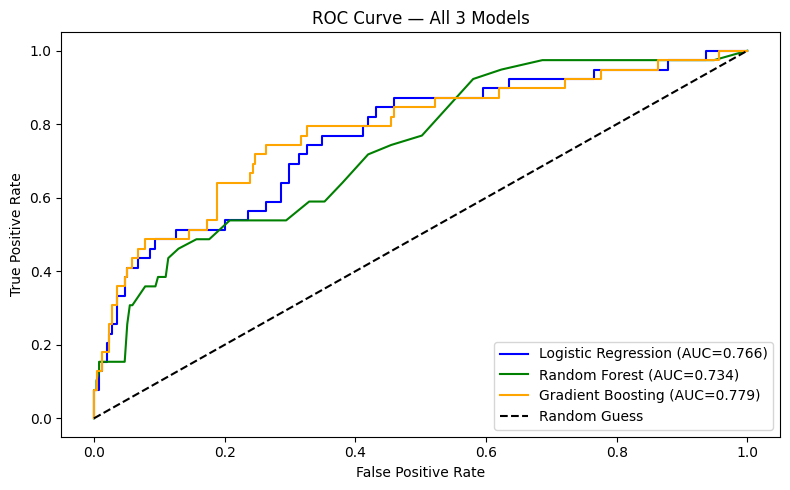

In [36]:
#Chart 5: ROC Curve comparing all 3 models on one graph
import os
os.makedirs('charts', exist_ok=True)
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 5))

for model, name, color in [(lr, 'Logistic Regression', 'blue'),
                            (rf, 'Random Forest', 'green'),
                            (gb, 'Gradient Boosting', 'orange')]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = round(roc_auc_score(y_test, model.predict_proba(X_test)[:,1]), 3)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc})', color=color)

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All 3 Models')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart5_roc_curve.png', dpi=150)
plt.show()

In [ ]:
#TASK 7 Starts

#Which 3 factors most strongly predict that an employee will leave?
YearsAtCompany (0.97), OverTime_Yes (0.93), and JobRole_Laboratory Technician (0.90) are the top 3 predictors that an employee will leave. #(numbers in the bracket represent the logistic regression coefficients)

#Which department or job role should HR prioritize for retention efforts?
Sales Representatives (39.8% attrition) and Laboratory Technicians (23.9%) are the highest risk roles, HR should focus retention efforts here first.

#Does salary alone explain attrition or are there other stronger factors?
Salary is a factor (leavers earn ~₹2000/month less) but YearsAtCompany, OverTime, and Job Role all rank higher as predictors.

#Write 2 concrete HR recommendations a company could implement based on your findings
1.Introduce an overtime monitoring policy- flag employees working consistent overtime for a check-in conversation, since OverTime is the 2nd strongest
predictor of exit.
2.Create a structured career progression plan for Sales Representatives and Laboratory Technicians in years 1-3 at the company, since both tenure and job role
are top drivers of attrition.

#What limitation does this model have that an HR team should be aware of before using it?
The model was trained on imbalanced data and still misses 41% of actual leavers (16 out of 39), so it should be used as a support tool for HR decisions,
not a definitive predictor.
